In [1]:
# load a matrix from a space-separated file and show it as an image
import sys
sys.path.append('/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/')
sys.path.append('/homes/ar2342/one_more_dir/contextual_frogs/')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import os
from stat_utils import bic_gaussian_from_rmse
from model_utils import force_model_params, migrate_output_scale_to_input_scale_state_dict



def compute_k_params(model_state_dict, 
                     exclude_by_startwith=['_'], 
                     exclude_by_name=['sigma_x'], 
                     count_for_one={'sigma_b', 'direct_injection_scale','output_scale','u_feedback_scale', 
                                    'x_slow_alpha', 'x_fast_gain', 'x_fast_alpha'}):
    k_params = 0
    for key in model_state_dict:
        if any([key.startswith(excl) for excl in exclude_by_startwith]):
            continue
        if key in exclude_by_name:
            continue
        param_tensor = model_state_dict[key]
        this_param_size = param_tensor.shape[-1] if key not in count_for_one else 1
        print(f'param: {key}, size: {this_param_size}')
        k_params += this_param_size
    return k_params

def read_rmse_and_bic_from_path(bic_path,seeds):
    model_state_dict = torch.load(os.path.join(bic_path, 'model_state_dict.pt'), map_location='cpu')
    k_params = compute_k_params(model_state_dict)
    print(f'detected k_params: {k_params}')
    a_exp = np.loadtxt(os.path.join(bic_path, 'a_exp.txt'))
    a_pred = np.loadtxt(os.path.join(bic_path, 'a_pred.txt'))

    subjs = a_exp.shape[1] // seeds
    print(f'detected subjs: {subjs}')

    se = np.nansum((a_exp - a_pred) ** 2,axis=0).reshape([subjs, seeds])
    bad_seeds = np.any(np.isnan(a_pred), axis=0).reshape([subjs, seeds])

    se = se + bad_seeds * 1e100

    # print(f'se: {se}')
    se_per_seed = np.sum(se, axis=0)
    print(f'se_per_seed: {se_per_seed}')
    best_seed = np.argmin(se_per_seed)
    seeds_ranked = np.argsort(se_per_seed)
    best_seed_idx = [best_seed + i*seeds for i in range(subjs)]
    print(f'best_seed_idx: {best_seed_idx}')

    rmse = np.sqrt(np.nanmean((a_exp - a_pred) ** 2,axis=0))
    n_samples = np.sum(~np.isnan(a_exp),axis=0).reshape([subjs, seeds])
    assert np.all(n_samples == n_samples[:, [0]])
    n_samples = n_samples[:, 0]

    # best_seed_idx = np.nanargmin(rmse, axis=1)
    best_rmse = rmse[best_seed_idx]
    best_bics = [bic_gaussian_from_rmse(this_rmse, n=this_n, k=k_params) for this_rmse, this_n in zip(best_rmse, n_samples)]
    return {"best_rmse": np.array(best_rmse), 
            "best_bics": np.array(best_bics), 
            'best_seed_idx': np.array(best_seed_idx),
            'seeds_ranked': seeds_ranked,
            'se_per_seed': se_per_seed,
            }


def myplot(data, color=None, style='-', label=None, align_by_endpoint=True, subj=[0,16], add_sem=True,**kwargs):
    if align_by_endpoint:
        x_data = np.arange(data.shape[0]) - (data.shape[0]-1)
    else:
        x_data = np.arange(data.shape[0])
    y_data = data[:, subj[0]:subj[1]]
    plt.plot(x_data, pooling_fun(y_data, axis=1), color=color, linestyle=style, label=label, **kwargs)
    if add_sem:
        n = np.sum(~np.isnan(y_data), axis=1)
        sem = np.divide(
            np.nanstd(y_data, axis=1, ddof=1),
            np.sqrt(n),
            out=np.zeros_like(x_data, dtype=float),
            where=n > 1,
        )
        plt.fill_between(
            x_data,
            pooling_fun(y_data, axis=1) - sem,
            pooling_fun(y_data, axis=1) + sem,
            color=color,
            alpha=0.2,
            linewidth=0,
        )

# default seed count
seeds = 128//2 # 128*2#*2 # 18#72#18 #128
#


#!!!
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/xlpfSftPlusV2WdepLRscaleOutClmpLRRecvov40m_inj0p4_with_seeds_1'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/xlpfSftPlusWdepLRscaleOutClmpLRRecvov40m_inj0p4_with_Nseeds_1'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/MEANxlpfSftPlusWdepLRscaleOutClmpLRRecvov40m_injX_with_Nseeds_1'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/MEAN3KxlpfSftPlusWdepLRscaleOutClmpLRRecvov40m_inj0p4_with_Nseeds_1'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/froB_MEANWZeroORDERxlpfSftPlusWdepLRscaleOutClmpLRRecvov40m_inj0p4_with_Nseeds_1'; at_y_eq_inf = 'skip_plasticity'
result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/froBmedian_MEANWZeroORDERxlpfSftPlusWdepLRscaleOutClmpLRRecvov40m_inj0p4_with_Nseeds_1'; at_y_eq_inf = 'skip_plasticity'

#Dual Rate:
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/DualRate_MEANWZeroORDERxlpfSftPlusWdepLRscaleOutClmpLRRecvov40m_inj0p4_with_Nseeds_1'; at_y_eq_inf = 'skip_slow_timescale_plasticity'



In [2]:
rcConf = {
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
}
# ufigx,ufigy = (8.5 / 2, 4.2 / 1.5)
ufigx,ufigy = (7.5 / 2, 4.2 / 1.5)

In [3]:
%history

# load a matrix from a space-separated file and show it as an image
import sys
sys.path.append('/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/')
sys.path.append('/homes/ar2342/one_more_dir/contextual_frogs/')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import os
from stat_utils import bic_gaussian_from_rmse
from model_utils import force_model_params, migrate_output_scale_to_input_scale_state_dict



def compute_k_params(model_state_dict, 
                     exclude_by_startwith=['_'], 
                     exclude_by_name=['sigma_x'], 
                     count_for_one={'sigma_b', 'direct_injection_scale','output_scale','u_feedback_scale', 
                                    'x_slow_alpha', 'x_fast_gain', 'x_fast_alpha'}):
    k_params = 0
    for key in model_state_dict:
        if any([key.startswith(excl) for excl in exclude_by_startwith]):
            continue
        if key in exclude_by_name:
            continue
      

In [4]:
#read saved model parameters
model_state_dict = torch.load(os.path.join(result_path, 'model_state_dict.pt'), map_location='cpu')
# if result_path_aux is not None:
#     model_state_dict_aux = torch.load(os.path.join(result_path_aux, 'model_state_dict.pt'), map_location='cpu')
# plt.hist(model_state_dict['output_scale'].cpu().numpy(), bins=30)
k_params = compute_k_params(model_state_dict)
print(f'detected k_params: {k_params}')

detected k_params: 0


In [5]:


a_exp = np.loadtxt(os.path.join(result_path, 'a_exp.txt'))
a_pred = np.loadtxt(os.path.join(result_path, 'a_pred.txt'))


# seeds = 128*2 # 128*2#*2 # 18#72#18 #128
# seeds = 128 # 128*2#*2 # 18#72#18 #128

subjs = a_exp.shape[1] // seeds

In [6]:
rmse = np.sqrt(np.nanmean((a_exp - a_pred) ** 2,axis=0)).reshape([subjs, seeds])

rmse_ = np.sqrt(np.nanmean((a_exp - a_pred)[192:,:] ** 2,axis=0)).reshape([subjs, seeds]) 
n_samples = np.sum(~np.isnan(a_exp),axis=0).reshape([subjs, seeds])
#ensure n_samples is same in every row
assert np.all(n_samples == n_samples[:, [0]])
n_samples = n_samples[:, 0]

seed_data = read_rmse_and_bic_from_path(result_path, seeds=seeds)
best_seed_idx = seed_data['best_seed_idx']

#sanity che


# best_seed_idx = np.nanargmin(rmse, axis=1)
# best_rmse = np.nanmin(rmse, axis=1)
best_rmse = rmse[np.arange(subjs), best_seed_idx%seeds]
best_rmse_ = rmse_[np.arange(subjs), best_seed_idx%seeds]

# best_seed_idx  = read_rmse_and_bic_from_path(result_path, seeds=seeds)['best_seed_idx']
# seed_data = read_rmse_and_bic_from_path(result_path, seeds=seeds)


/tmp/ipykernel_3875500/4215794704.py:1: RuntimeWarning: Mean of empty slice
  rmse = np.sqrt(np.nanmean((a_exp - a_pred) ** 2,axis=0)).reshape([subjs, seeds])
/tmp/ipykernel_3875500/4215794704.py:3: RuntimeWarning: Mean of empty slice
  rmse_ = np.sqrt(np.nanmean((a_exp - a_pred)[192:,:] ** 2,axis=0)).reshape([subjs, seeds])


detected k_params: 0
detected subjs: 16
se_per_seed: [6.25785234e+001 6.18425458e+001 1.71226117e+002 6.21110384e+001
 6.17865934e+001 6.18773580e+001 1.71207377e+002 6.21010634e+001
 1.71460880e+002 6.28232051e+001 6.17899836e+001 1.71387572e+002
 1.71617684e+002 6.20416766e+001 1.70236491e+002 6.18161745e+001
 1.71748766e+002 1.69816208e+002 1.71270522e+002 1.71266005e+002
 6.47553307e+001 6.55832232e+001 6.27338985e+001 6.46671361e+001
 6.22970649e+001 6.56611789e+001 6.17536347e+001 1.71383980e+002
 1.71568568e+002 1.60000000e+101 6.75785717e+001 6.64442830e+001
 6.17536383e+001 6.17540021e+001 6.18503430e+001 6.19582763e+001
 1.71231894e+002 6.86139229e+001 6.17535875e+001 6.17706815e+001
 6.19289061e+001 1.71228138e+002 1.71613290e+002 1.70469403e+002
 6.83074149e+001 1.71615442e+002 6.50532335e+001 1.71605764e+002
 1.71563868e+002 6.17591070e+001 1.70959664e+002 6.17540207e+001
 1.71596264e+002 1.71348142e+002 6.18926497e+001 1.71613951e+002
 6.55854800e+001 1.70221610e+002 6.77

/tmp/ipykernel_3875500/1613825591.py:55: RuntimeWarning: Mean of empty slice
  rmse = np.sqrt(np.nanmean((a_exp - a_pred) ** 2,axis=0))


Text(0, 0.5, 'adaptation')

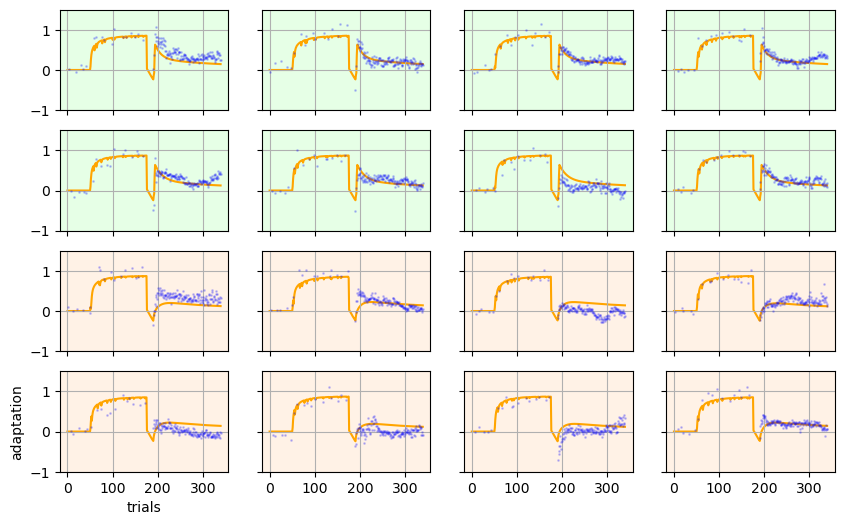

In [7]:
lerner_switch = False


plt.figure(figsize=(10, 6))
plt.subplot(4, 4, 1)
cnt=0
for ii, (this_exp, this_pred) in enumerate(zip(a_exp.T, a_pred.T)):
    this_sub = ii//seeds
    plt.subplot(4, 4, 1 + this_sub)
    polarity = np.sign(np.nanmean(this_exp[:175]))
    if ii % seeds == 0:
        plt.plot(polarity*this_exp,'.', label='Experimental', color='blue', markersize=2, alpha=0.2)
    # if ii == best_seed_idx[this_sub]:
    if ii % seeds == best_seed_idx[0]:
        plt.plot(polarity*this_pred, label='Predicted', color='orange',zorder=0)
        plt.grid() #; print(cnt); cnt+=1
        plt.ylim([-1,1.5])

    if this_sub % 4 > 0:
        plt.gca().set_yticklabels([])
    if this_sub < 12:
        plt.gca().set_xticklabels([])

    if not lerner_switch:
        if this_sub <8:
            # plt.axvspan(0, 340, color='green', alpha=0.01)
            plt.gca().set_facecolor((0.9,1,0.9))
        else:
            # plt.axvspan(0,340, color='orange', alpha=0.1)
            plt.gca().set_facecolor((1,0.95,0.9))
    else:
        if this_sub <15:
            # plt.axvspan(0, 340, color='green', alpha=0.01)
            plt.gca().set_facecolor((0.9,0.9,1))
        else:
            # plt.axvspan(0,340, color='orange', alpha=0.1)
            plt.gca().set_facecolor((0.8,0.7,1))
plt.subplot(4, 4, 13)
plt.xlabel('trials')
plt.ylabel('adaptation')
# plt.title('Experimental vs Predicted Data')
# plt.savefig('/homes/ar2342/one_more_dir/contextual_frogs/figs/ersrFitsM19.pdf', format='pdf', bbox_inches='tight')# 
# plt.savefig('/homes/ar2342/one_more_dir/contextual_frogs/figs/lernerFitsM19.pdf', format='pdf', bbox_inches='tight')

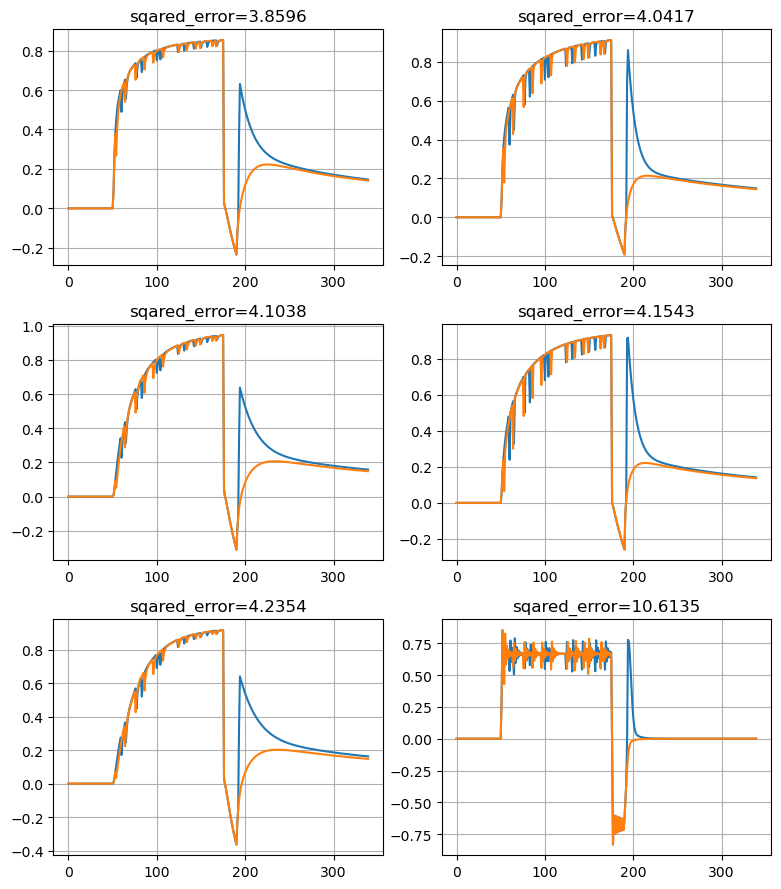

In [8]:
plt.figure(figsize=(8, 9))

prev_pred_ER = np.zeros_like(a_pred[:,0])
prev_pred_SR = np.zeros_like(a_pred[:,64*15]) #64 seeds times 8 participants
skipped = 0
jj = 1
for ii, ss in enumerate(seed_data['seeds_ranked']):
    this_pred_ER = a_pred[:, ss]  
    this_pred_SR = a_pred[:, ss + 64*15] 
    if np.isnan(this_pred_ER).any() or np.isnan(this_pred_SR).any():
        print(f'Found NaN in prediction for seed index {ss}')
    else:
        this_diff_ER = np.abs(this_pred_ER - prev_pred_ER).max()
        this_diff_SR = np.abs(this_pred_SR - prev_pred_SR).max()
        if this_diff_ER > 10e-2 or this_diff_SR > 10e-2:
            plt.subplot(3, 2, jj)

            plt.plot(this_pred_ER)
            plt.plot(this_pred_SR)
            plt.grid()
            # plt.title(f'Seed index {ss}, max diff from previous:\nER={this_diff_ER:.4f}, SR={this_diff_SR:.4f}\n sqared_error={seed_data["se_per_seed"][ss]}\n skipped {skipped} seeds so far')
            plt.title(f'sqared_error={seed_data["se_per_seed"][ss]/16:.4f}')
            skipped = 0
            jj += 1
            if jj > 6:
                break
        else:
            skipped +=1
        prev_pred_ER = this_pred_ER + 0.
        prev_pred_SR = this_pred_SR + 0.
plt.tight_layout()

In [9]:
# np.savetxt('/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/dual_rateNL_bics_v1.txt', these_bics)

In [10]:
best_seed_idx_within_batch = np.array([best_seed_idx[0]]*16) # +(np.arange(subjs) * seeds)

#create a new model state dict with only the best seeds (seeds are the leading dimension of each parameter tensor)
best_model_state_dict = {}
for key, value in model_state_dict.items():
        print(key, value.shape)
        if key.endswith('_periodic_base'):
                cropped_key = key[:-len('_periodic_base')]
                cropper_key = cropped_key[1:]
                best_model_state_dict[cropper_key] = value[best_seed_idx_within_batch]
        else:
                best_model_state_dict[key] = value


_log_learning_rate_periodic_base torch.Size([64, 1])
_log_learning_rate_decay_periodic_base torch.Size([64, 1])
_output_scale_periodic_base torch.Size([64])
_sp_weight_decay_periodic_base torch.Size([64, 1])
_sigma_x_periodic_base torch.Size([64])
_x_fast_alpha_periodic_base torch.Size([64])
_sigma_b_periodic_base torch.Size([64])
_input_scale_periodic_base torch.Size([64])
_u_feedback_scale_periodic_base torch.Size([64])
_weight_decay_exp_periodic_base torch.Size([64, 1])
_weight_learning_exp_periodic_base torch.Size([64, 1])
_q_scale_periodic_base torch.Size([64])
_bias_lr_periodic_base torch.Size([64])
_tauqlpf_m1_periodic_base torch.Size([64])
_tauylpf_m1_periodic_base torch.Size([64])
_tauelpf_m1_periodic_base torch.Size([64])
_direct_injection_scale_periodic_base torch.Size([64])
_z_biases torch.Size([1024])
_w_in torch.Size([1024])
_w_inq torch.Size([1024])


In [11]:
from models_part2 import BatchedElboGenerativeModelTopMulti
import yaml
from types import SimpleNamespace
args_path = os.path.join(result_path, 'args.yaml')
with open(args_path, 'r') as f:
    args_dict = yaml.unsafe_load(f) #safe_load(f)
args = SimpleNamespace(**args_dict)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

args.bs = subjs  #set batch size to number of subjects


In [12]:
import pickle

In [13]:
'''
sort the rates for dual rate settinig in a correct order
'''

args.at_y_eq_inf = at_y_eq_inf
if at_y_eq_inf=="skip_slow_timescale_plasticity":
    #ensure that in best_model_state_dict learning rates are sorted from low to high (and weight decays accordingly)
    #'log_learning_rate', 'sp_weight_decay' are the effected parameters
    # lr_order = np.argsort(best_model_state_dict['log_learning_rate'])
    # sorted_lr = best_model_state_dict['log_learning_rate'][:,lr_order]
    # sorted_weight_decay = best_model_state_dict['sp_weight_decay'][:,lr_order]

    sorted_lr, lr_order = torch.sort(best_model_state_dict['log_learning_rate'], dim=1, descending=False)
    sorted_weight_decay = torch.gather(best_model_state_dict['sp_weight_decay'], dim=1, index=lr_order)
    best_model_state_dict['log_learning_rate'] = sorted_lr
    best_model_state_dict['sp_weight_decay'] = sorted_weight_decay

In [14]:
model = BatchedElboGenerativeModelTopMulti(device=device, args=args, 
                                           **(dict(fudge=args.fudge) if hasattr(args, 'fudge') else {}  )).to(device)
model.get_biases_and_w_in(args.n, device=device)
model.load_state_dict(best_model_state_dict, strict=False) #allow missing keys since we may have removed the output scale parameters during migration

_IncompatibleKeys(missing_keys=[], unexpected_keys=['sigma_b', 'input_scale', 'u_feedback_scale', 'weight_decay_exp', 'weight_learning_exp', 'q_scale', 'bias_lr', 'tauqlpf_m1', 'tauylpf_m1', 'tauelpf_m1', 'direct_injection_scale'])

In [15]:
# best_model_state_dict = migrate_output_scale_to_input_scale_state_dict(best_model_state_dict, remove_output_scale=True)


In [16]:
def eval_single_paradigm(model, 
                         paradigm, 
                         args, 
                         paradigm_name=None, 
                         record_internals=False, 
                         record_vectors=False,
                         noise_spikes=[]):
    if paradigm_name is not None:
        print(f"evaluating paradigm {paradigm_name} with {len(paradigm)} steps")
    ys = torch.tensor(paradigm, device=next(model.parameters()).device)
    # duplicate ys across batch size
    ys = ys.unsqueeze(0).repeat(args.bs, 1)  # [bs, t]
    # noises = torch.randn((args.bs, ys.shape[1]), device=next(model.parameters()).device) * model.sigma_x  # [bs, t]
    noises = torch.zeros((args.bs, ys.shape[1]), device=next(model.parameters()).device)  # [bs, t]
    for t in noise_spikes:
        if t < noises.shape[1]:
            noises[:, t] = 1

    noises = [noises[:, t_idx] for t_idx in range(noises.shape[1])]
    ys = [ys[:, t_idx] for t_idx in range(ys.shape[1])]
    if paradigm_name is not None:
        print(f"noises shape: {noises[0].shape}, ys shape: {ys[0].shape}")
    model_setting = args.model
    outputs_ = model.f(
        args.n,
        noises,
        ys,
        model_setting,
        qs=None,
        record_internals=record_internals,
        record_vectors=record_vectors,
    )
    if record_internals:
        outputs_, internals = outputs_
        return outputs_, internals
    return outputs_, None


def local_eval_paradigms(model, playlist_file, args, record_internals=False, record_vectors=False):
    with open(playlist_file, "rb") as f:
        playlist = pickle.load(f)

    model.eval()
    with torch.no_grad():
        outputs = {}
        internals_by_paradigm = {} if record_internals else None
        for paradigm_name, paradigm in playlist.items():
            outputs_, internals = eval_single_paradigm(
                model,
                paradigm,
                args,
                paradigm_name=paradigm_name,
                record_internals=record_internals,
                record_vectors=record_vectors,
            )
            outputs[paradigm_name] = np.array([z.cpu().numpy().reshape(-1) for z in outputs_])
            if record_internals:
                internals_by_paradigm[paradigm_name] = internals
    if record_internals:
        return outputs, internals_by_paradigm
    return outputs

def eval_single_wrap(model, paradigm, args, paradigm_name=None, record_internals=False, record_vectors=False):
    outputs, internals = eval_single_paradigm(model, paradigm, args, paradigm_name, record_internals, record_vectors)
    outputs = [o.detach().cpu().numpy() for o in outputs]
    outputs = np.array(outputs)
    if record_internals:
        # for k in internals:
        #     internals[k] = {kk: vv.detach().cpu().numpy() for kk, vv in internals[k].items()}
        return outputs, internals
    return outputs, None

In [17]:
def find_fixed_points(x_values, y_values, tol=1e-3, selection='closest_to_zero'):
    x_values = np.asarray(x_values, dtype=np.float32)
    y_values = np.asarray(y_values, dtype=np.float32)

    if y_values.ndim == 1:
        y_values = y_values[None, :]

    fixed_points = []
    for y in y_values:
        diffs = y - x_values
        candidates = []

        close_idx = np.where(np.abs(diffs) <= tol)[0]
        # candidates.extend(x_values[close_idx].tolist())

        sign_changes = np.where(np.signbit(diffs[:-1]) != np.signbit(diffs[1:]))[0]
        for idx in sign_changes:
            x0, x1 = x_values[idx], x_values[idx + 1]
            d0, d1 = diffs[idx], diffs[idx + 1]
            # if np.isclose(d0, d1):
            #     crossing = 0.5 * (x0 + x1)
            # else:
            crossing = x0 - d0 * (x1 - x0) / (d1 - d0)
            # print(f'crossing: {crossing}, x0: {x0}, x1: {x1}, d0: {d0}, d1: {d1}')
            candidates.append(float(crossing))

        if not candidates:
            fixed_points.append(np.nan)
            continue
        # print(f'candidates before rounding and sorting: {candidates}')
        candidates = np.array(sorted(set(np.round(candidates, 8))), dtype=np.float32)
        # print(f'candidates after rounding and sorting: {candidates}')
        if selection == 'closest_to_zero':
            fixed_points.append(candidates[np.argmin(np.abs(candidates))])
        elif selection == 'first':
            fixed_points.append(candidates[0])
        elif selection == 'last':
            fixed_points.append(candidates[-1])
        else:
            raise ValueError(f'Unknown selection mode: {selection}')

    return np.asarray(fixed_points, dtype=np.float32)


In [18]:
def eval_paradigm_with_inoutmaps(model, args, paradigm, probe_values, *, name=None):
    if name is not None:
        print(f"evaluating {name} with {len(paradigm)} steps")

    device = next(model.parameters()).device
    ys_tensor = torch.tensor(paradigm, device=device).unsqueeze(0).repeat(args.bs, 1)
    noise_tensor = torch.zeros_like(ys_tensor)
    ys_list = [ys_tensor[:, t_idx] for t_idx in range(ys_tensor.shape[1])]
    noise_list = [noise_tensor[:, t_idx] for t_idx in range(noise_tensor.shape[1])]

    outputs = None
    inoutmaps = []

    model.eval()
    with torch.no_grad():
        for probe_value in probe_values:
            probing_vec = torch.full((args.bs,), float(probe_value), device=device)
            outputs_raw, inoutmaps_raw = model.f(
                args.n,
                noise_list,
                ys_list,
                args.model,
                qs=None,
                record_inoutmaps=True,
                inoutmaps_probing_vec=probing_vec,
            )

            if outputs is None:
                outputs = np.stack([
                    z.detach().cpu().numpy().reshape(-1) for z in outputs_raw
                ], axis=0)

            inoutmaps.append(np.stack([
                hidden.detach().cpu().numpy().reshape(-1) for hidden, _ in inoutmaps_raw
            ], axis=0))

    inoutmaps = np.stack(inoutmaps, axis=0)
    inoutmaps = np.moveaxis(inoutmaps, 0, -1)
    fixed_points = np.stack([
        find_fixed_points(probe_values, inoutmaps[:, subj_idx, :])
        for subj_idx in range(outputs.shape[1])
    ], axis=1)

    trial_idx = np.arange(len(paradigm))
    output_mean = outputs.mean(axis=1)
    fixed_point_mean = np.nanmean(fixed_points, axis=1)

    return {
        'name': name,
        'paradigm': paradigm,
        'outputs': outputs,
        'output_mean': output_mean,
        'inoutmaps': inoutmaps,
        'fixed_points': fixed_points,
        'fixed_point_mean': fixed_point_mean,
        'trial_idx': trial_idx,
    }


In [19]:
# Compare P+ duration 100 (solid) vs 150 (dashed) for a single subject.
subj_idx = 3  # change this to pick a different subject (0-based index)
probe_values = np.arange(-0.5, 1.5 + 0.05 / 2, 0.025, dtype=np.float32)

ref_paradigm = np.concatenate([
    np.zeros(50, dtype=np.float32),
    np.ones(200, dtype=np.float32),
    np.full(650, np.nan, dtype=np.float32),
])


ref_outs = eval_paradigm_with_inoutmaps(
    model,
    args,
    ref_paradigm,
    probe_values,
    name='ref',
)

evaluating ref with 900 steps


In [20]:
savepath  = ('/homes/ar2342/one_more_dir/contextual_frogs/gnu_fig_data/allSubFit/conceptParadigm_v3medianB/')

In [21]:
this_input_scale = model.softclamp(best_model_state_dict['output_scale'])[subj_idx].detach().cpu().numpy()


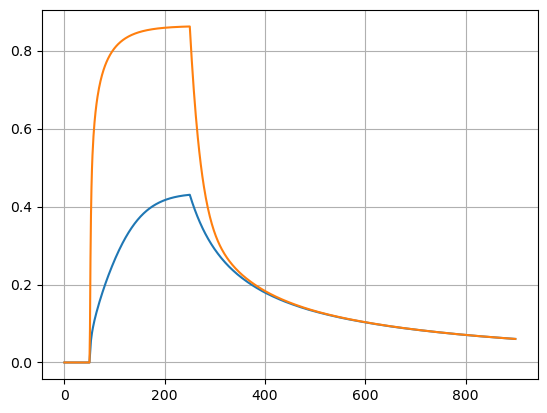

In [23]:
plt.plot(ref_outs['fixed_points'][:, subj_idx]*this_input_scale)
plt.plot(ref_outs['outputs'][:, subj_idx])
plt.grid()

np.savetxt(os.path.join(savepath, 'fixed_points.txt'), ref_outs['fixed_points'][:, subj_idx]*this_input_scale)
np.savetxt(os.path.join(savepath, 'outputs.txt'), ref_outs['outputs'][:, subj_idx])


In [24]:
_, ref_outs_internals = eval_single_wrap(model, ref_paradigm, args, paradigm_name='ref', record_internals=True)

evaluating paradigm ref with 900 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])


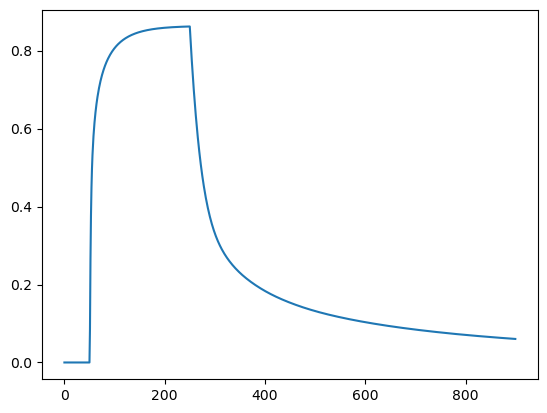

In [25]:
plt.plot(ref_outs['outputs'][:, subj_idx])

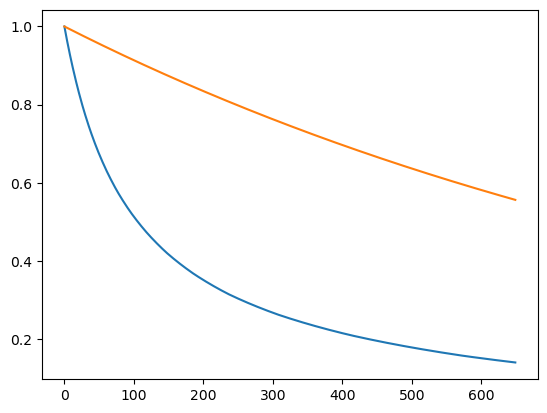

In [26]:
y = ref_outs['fixed_points'][250:, subj_idx]
# plt.semilogy(y/y[0])
fixed_point_decay = y/y[0]
plt.plot(fixed_point_decay)
y = ref_outs_internals['w_out_norm'].squeeze().detach().cpu().numpy()[250:,0]
# plt.semilogy(y/y[0])
w_out_norm_decay = y/y[0]
plt.plot(w_out_norm_decay)

np.savetxt(os.path.join(savepath, 'fixed_point_decay.txt'), fixed_point_decay)
np.savetxt(os.path.join(savepath, 'w_out_norm_decay.txt'), w_out_norm_decay)
full_w_out_trajectory = ref_outs_internals['w_out_norm'].squeeze().detach().cpu().numpy()[:,0]
np.savetxt(os.path.join(savepath, 'full_w_out_trajectory.txt'), full_w_out_trajectory)
np.savetxt(os.path.join(savepath, 'full_w_out_trajectory_normalized.txt'), full_w_out_trajectory/np.abs(full_w_out_trajectory).max())

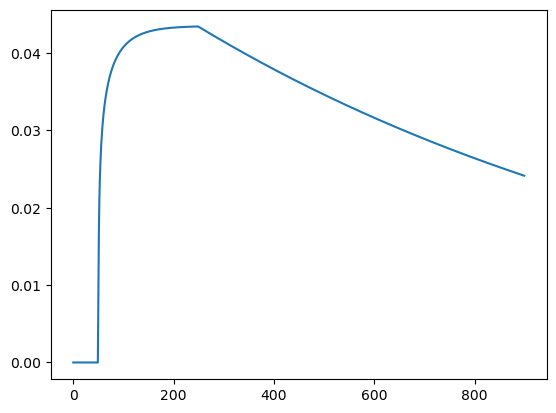

In [27]:
plt.plot(ref_outs_internals['w_out_norm'].squeeze().detach().cpu().numpy()[:,0])

In [28]:
_, ref_outs_internals_sanity = eval_single_wrap(model, np.concatenate([ref_paradigm,np.full(1500, np.nan, dtype=np.float32)]), args, paradigm_name='ref', record_internals=True)

evaluating paradigm ref with 2400 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])


In [29]:
# plt.plot(ref_outs_internals_sanity['w_out_norm'].squeeze().detach().cpu().numpy()[250:,0]/ref_outs_internals_sanity['w_out_norm'].squeeze().detach().cpu().numpy()[250,0])

In [31]:
t_adapts = np.arange(0,201,25)
t_evoke = 5

decay_paradigms = [np.concatenate([
    np.zeros(50, dtype=np.float32),
    np.ones(t_adapt, dtype=np.float32),
    np.ones(t_evoke, dtype=np.float32),
    np.full(200, np.nan, dtype=np.float32),
]) for t_adapt in t_adapts]

decay_outs = [eval_single_wrap(model, paradigm, args, paradigm_name=f'decay_{t_adapt}', record_internals=True) for t_adapt, paradigm in zip(t_adapts, decay_paradigms)]

evaluating paradigm decay_0 with 255 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm decay_25 with 280 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm decay_50 with 305 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm decay_75 with 330 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm decay_100 with 355 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm decay_125 with 380 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm decay_150 with 405 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm decay_175 with 430 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm decay_200 with 455 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])


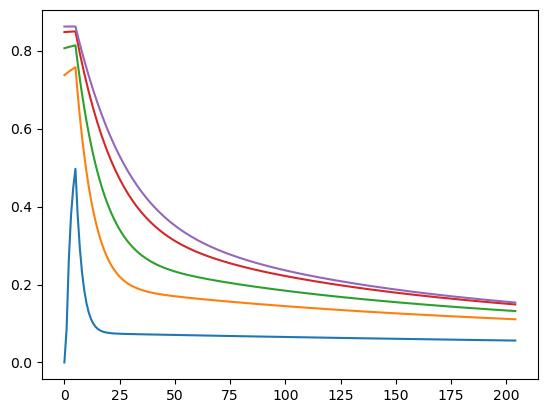

In [32]:
to_show = [0, 25,50,100,200]
for t_adapt, (decay_out, decay_internals) in zip(t_adapts, decay_outs):
    if t_adapt not in to_show:
        continue
    y = decay_out[50+t_adapt:, subj_idx]
    plt.plot(y)
    np.savetxt(os.path.join(savepath, f'adaptation_whatif_decay_{t_adapt}.txt'), y)

In [33]:
t_pre_recalls = np.arange(0,251,25)
recall_paradigms = [np.concatenate([
    np.zeros(50, dtype=np.float32),
    np.ones(200, dtype=np.float32),
    np.full(t_recall, np.nan, dtype=np.float32),
    np.full(5, np.nan, dtype=np.float32),
    np.ones(t_evoke, dtype=np.float32),
    np.full(200, np.nan, dtype=np.float32),
]) for t_recall in t_pre_recalls]

recall_outs = [eval_single_wrap(model, paradigm, args, paradigm_name=f'recall_{t_recall}', record_internals=True) for t_recall, paradigm in zip(t_pre_recalls, recall_paradigms)]

evaluating paradigm recall_0 with 460 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm recall_25 with 485 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm recall_50 with 510 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm recall_75 with 535 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm recall_100 with 560 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm recall_125 with 585 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm recall_150 with 610 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm recall_175 with 635 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm recall_200 with 660 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm recall_225 with 685 steps
noises shape: 

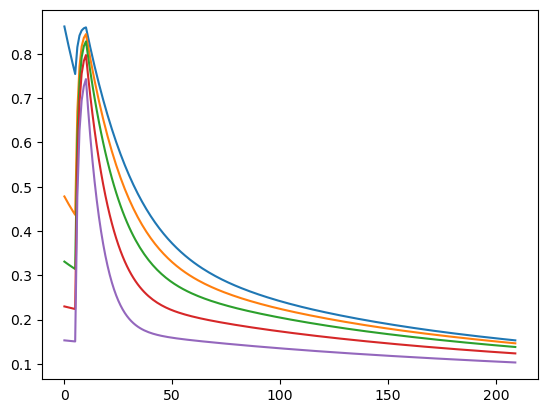

In [34]:
for t_recall, (recall_out, recall_internals) in zip(t_pre_recalls, recall_outs):
    if t_recall not in to_show:
        continue
    y = recall_out[240+t_recall+10:, subj_idx]
    plt.plot(y)
    np.savetxt(os.path.join(savepath, f'recall_whatif_decay_{t_recall}.txt'), y)

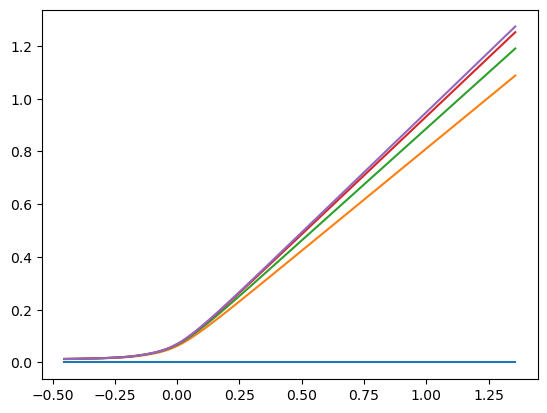

In [35]:
for t in to_show:
    y = ref_outs['inoutmaps'][50 + t, subj_idx, :] *this_input_scale
    x = probe_values * this_input_scale
    plt.plot(x, y)
    np.savetxt(os.path.join(savepath, f'adaptation_inoutmap_{t}.txt'), np.stack((x, y)).T)

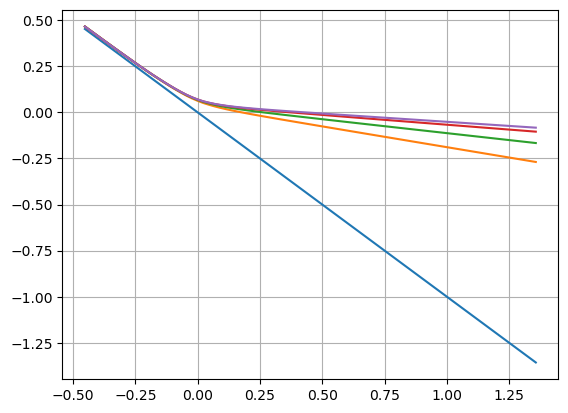

In [36]:
for t in to_show:
    y = ref_outs['inoutmaps'][50 + t, subj_idx, :] * this_input_scale
    x = probe_values * this_input_scale
    plt.plot(x, y-x)
    np.savetxt(os.path.join(savepath, f'adaptation_driftmap_{t}.txt'), np.stack((x, y-x)).T)
    plt.grid()

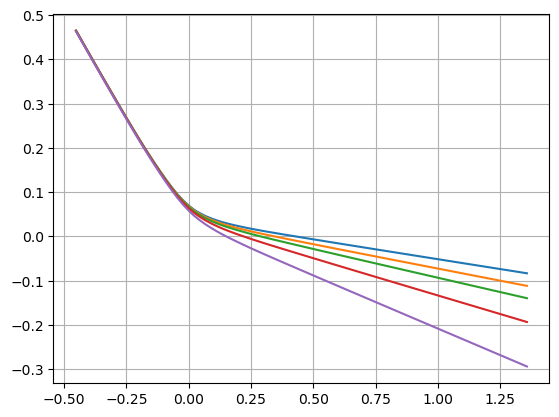

In [37]:
for t in to_show:
    y = ref_outs['inoutmaps'][250 + t, subj_idx, :] *this_input_scale
    x = probe_values * this_input_scale
    plt.plot(x, y-x)
    np.savetxt(os.path.join(savepath, f'channel_driftmap_{t}.txt'), np.stack((x, y-x)).T)
    np.savetxt(os.path.join(savepath, f'channel_inoutmap_{t}.txt'), np.stack((x, y)).T)

    plt.grid()

In [38]:
np.column_stack((x, y))

array([[-4.5230913e-01,  1.0895364e-02],
       [-4.2969367e-01,  1.1091244e-02],
       [-4.0707821e-01,  1.1340944e-02],
       [-3.8446274e-01,  1.1657744e-02],
       [-3.6184728e-01,  1.2026128e-02],
       [-3.3923182e-01,  1.2488592e-02],
       [-3.1661636e-01,  1.3047709e-02],
       [-2.9400089e-01,  1.3682166e-02],
       [-2.7138543e-01,  1.4422134e-02],
       [-2.4876997e-01,  1.5288692e-02],
       [-2.2615451e-01,  1.6345832e-02],
       [-2.0353904e-01,  1.7674422e-02],
       [-1.8092358e-01,  1.9405812e-02],
       [-1.5830812e-01,  2.1728797e-02],
       [-1.3569267e-01,  2.4409736e-02],
       [-1.1307720e-01,  2.7614608e-02],
       [-9.0461738e-02,  3.1412743e-02],
       [-6.7846276e-02,  3.6147505e-02],
       [-4.5230817e-02,  4.1862220e-02],
       [-2.2615355e-02,  4.9278561e-02],
       [ 1.0783890e-07,  5.8325317e-02],
       [ 2.2615543e-02,  6.8889812e-02],
       [ 4.5231033e-02,  8.1544265e-02],
       [ 6.7846522e-02,  9.5040455e-02],
       [ 9.04619

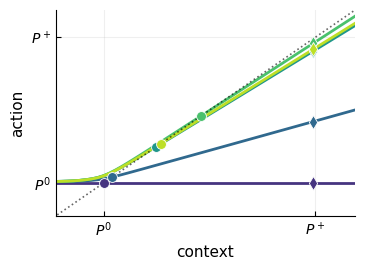

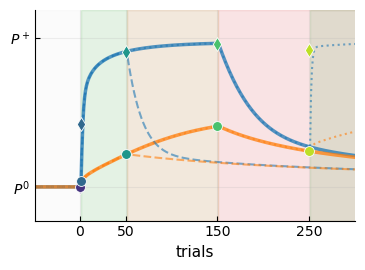

In [ ]:
# generate input-output map for the subject, with fixed-point markers
# Preps for FIG 1

plt.rcParams.update(rcConf)

enable_title_and_labels = False

subj_idx = 0  # change this for a different subject
pnt_size = 50
fig_scale = 3./4
time_steps = [50, 51, 100, 200, 300]
this_input_scale = model.softclamp(best_model_state_dict['output_scale'])[subj_idx].detach().cpu().numpy()
Pert = this_input_scale * 1
idx_pert = np.argmin(np.abs(probe_values-Pert))
x_pert = probe_values[idx_pert]
eval_ref = eval_pplus150  # use the P+ = 150 exposure condition

fixed_points = eval_ref['fixed_points'][:, subj_idx]
trial_idx = eval_ref['trial_idx'] - 50
outputs = eval_ref['outputs'][:, subj_idx]

fixed_points_pplus50 = eval_pplus50['fixed_points'][:, subj_idx]
trial_idx_pplus50 = eval_pplus50['trial_idx'] - 50
outputs_pplus50 = eval_pplus50['outputs'][:, subj_idx]

fixed_points_pplus150pplus50 = eval_pplus150pplus50['fixed_points'][:, subj_idx]
trial_idx_pplus150pplus50 = eval_pplus150pplus50['trial_idx'] - 50
outputs_pplus150pplus50 = eval_pplus150pplus50['outputs'][:, subj_idx]

colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(time_steps)))

# fig, (ax_map, ax_traj) = plt.subplots(1, 2, figsize=(11*fig_scale, 4.5*fig_scale))
fig1, ax_map = plt.subplots(figsize=(ufigx, ufigy))
fig2, ax_traj = plt.subplots(figsize=(ufigx, ufigy))
# Input-output maps with fixed-point dots
for color, t in zip(colors, time_steps):
    if t >= eval_ref['inoutmaps'].shape[0]:
        continue
    y_map = eval_ref['inoutmaps'][t, subj_idx, :]
    ax_map.plot(
        probe_values,
        y_map,
        color=color,
        linewidth=2.0,
        label=f't={t-50}',
    )
    ax_map.scatter(
        fixed_points[t],
        fixed_points[t],
        s=pnt_size,
        color=color,
        edgecolor='white',
        linewidth=0.6,
        zorder=5,
    )
    ax_traj.scatter(
        trial_idx[t],
        y_map[idx_pert],
        s=pnt_size,
        color=color,
        marker='d',
        edgecolor='white',
        linewidth=0.6,
        zorder=5,
    )

    ax_map.scatter(
        probe_values[idx_pert],
        y_map[idx_pert],
        s=pnt_size,
        color=color,
        marker='d',
        edgecolor='white',
        linewidth=0.6,
        zorder=5,
    )

adapt_lims = [-0.2, 1.05]
ax_map.plot(probe_values, probe_values, 'k:', linewidth=1.2, alpha=0.6, label='identity')
if enable_title_and_labels:
    ax_map.set_xlabel('input')
    ax_map.set_ylabel('output')
    ax_map.set_title('feed-forward \n in-out mapping')
ax_map.set_xlim(adapt_lims)
ax_map.set_ylim(adapt_lims)
ax_map.grid(alpha=0.2)
# ax_map.legend(frameon=False, title='trials from \nP+ onset', loc='upper left')

# Trajectories with fixed-point markers
x_traj = trial_idx + 1
x_traj_50 = trial_idx_pplus50 + 1

# Background shading for phases (P0, P+, Pc)
p0_start, p0_end = -49, 0
pplus50_start, pplus50_end = 1, 51
pplus150_start, pplus150_end = 1, 151
pc50_start, pc50_end = 51, 301
pc150_start, pc150_end = 151, 301
overlap_start, overlap_end = 51, 151
pplus50_recall_start, pplus50_recall_end = 251, 301

ax_traj.axvspan(p0_start-20, p0_end, color='0.8', alpha=0.08, zorder=0)
ax_traj.axvspan(pplus50_start, pplus50_end, color='tab:green', alpha=0.08, zorder=0)
ax_traj.axvspan(pplus150_start, pplus150_end, color='tab:green', alpha=0.05, zorder=0)
ax_traj.axvspan(pc50_start, pc50_end, color='tab:red', alpha=0.05, zorder=0)
ax_traj.axvspan(pc150_start, pc150_end, color='tab:red', alpha=0.08, zorder=0)
ax_traj.axvspan(overlap_start, overlap_end, color='tab:orange', alpha=0.06, zorder=0)
# Extra perturbation phase for dotted paradigm (last 50 trials)
ax_traj.axvspan(pplus50_recall_start, pplus50_recall_end, color='tab:green', alpha=0.12, zorder=0)

label_y = 0.02
# ax_traj.text((p0_start + p0_end) / 2, label_y, 'P0', transform=ax_traj.get_xaxis_transform(), ha='center', va='bottom', color='0.35')
# ax_traj.text((pplus50_start + pplus50_end) / 2, label_y, 'P+', transform=ax_traj.get_xaxis_transform(), ha='center', va='bottom', color='0.35')
# ax_traj.text((overlap_start + overlap_end) / 2, label_y, 'P+ \n(Pc)', transform=ax_traj.get_xaxis_transform(), ha='center', va='bottom', color='0.35')
# ax_traj.text((pc150_start + pc150_end) / 2, label_y, 'Pc', transform=ax_traj.get_xaxis_transform(), ha='center', va='bottom', color='0.35')
# ax_traj.text((pplus50_recall_start + pplus50_recall_end) / 2, label_y, 'Pc \n(P+)', transform=ax_traj.get_xaxis_transform(), ha='center', va='bottom', color='0.35')

ax_traj.plot(x_traj, outputs, color='tab:blue', linewidth=2.5, alpha=0.75, linestyle='-')
ax_traj.plot(x_traj, fixed_points*Pert, color='tab:orange', linewidth=2.5, alpha=0.75,linestyle='-')

# Add P+ = 50 trajectories (dashed)
thin_line_width = 1.5
ax_traj.plot(
    x_traj_50,
    outputs_pplus50,
    color='tab:blue',
    linewidth=thin_line_width,
    alpha=0.6,
    linestyle='--', label='output',
 )
ax_traj.plot(
    x_traj_50,
    fixed_points_pplus50*Pert,
    color='tab:orange',
    linewidth=thin_line_width,
    alpha=0.6,
    linestyle='--', label='fixed point',
 )

 # Add recall P+ trajectories (dotted)
ax_traj.plot(
    x_traj_50,
    outputs_pplus150pplus50,
    color='tab:blue',
    linewidth=thin_line_width,
    alpha=0.6,
    linestyle=':', label='output',
 )
ax_traj.plot(
    x_traj_50,
    fixed_points_pplus150pplus50*Pert,
    color='tab:orange',
    linewidth=thin_line_width,
    alpha=0.6,
    linestyle=':', label='fixed point',
 )
#
for color, t in zip(colors, time_steps):
    if t >= trial_idx.shape[0]:
        continue
    ax_traj.scatter(
        trial_idx[t],
        fixed_points[t]*Pert,
        s=pnt_size,
        color=color,
        edgecolor='white',
        linewidth=0.6,
        zorder=5,
    )

if enable_title_and_labels:
    ax_traj.set_xlabel('trials')
    ax_traj.set_ylabel('adaptation')
    ax_traj.set_title('adaptation trajectories')
ax_traj.grid(alpha=0.2)
ax_traj.set_ylim(adapt_lims)

# Legend for signal colors
# signal_legend = ax_traj.legend(frameon=False, loc='upper right', title='signal')
# ax_traj.add_artist(signal_legend)

# Legend for line styles
# style_handles = [
#     plt.Line2D([0], [0], color='0.4', linewidth=2.4, linestyle='-', label='50'),
#     plt.Line2D([0], [0], color='0.4', linewidth=2.4, linestyle='--', label='150'),
# ]
# ax_traj.legend(handles=style_handles, frameon=False, loc='upper left', title='P+ duration')

ax_traj.set_xticks([0,50,150,250])
ax_traj.set_xlabel('trials')
ax_traj.set_yticks([0, Pert])
ax_traj.set_yticklabels(['$P^0$', '$P^+$'])

ax_map.set_yticks([0, Pert])
ax_map.set_yticklabels(['$P^0$', '$P^+$'])
ax_map.set_xlabel('context')
ax_map.set_ylabel('action')

ax_map.set_xticks([0, Pert])
ax_map.set_xticklabels(['$P^0$', '$P^+$'])
response_x_min, response_x_max = x_traj_50[0], x_traj_50[-1]
ax_traj.set_xlim(response_x_min, response_x_max)

for this_ax in [ax_map, ax_traj]:
    this_ax.tick_params(axis='y',which='both',direction='in',right=False)
    this_ax.tick_params(axis='x',which='both',direction='in',right=False)

fig1.tight_layout()
# fig1.savefig('fig1CvJn3.svg',format='svg')
fig2.tight_layout()
# fig2.savefig('fig1DvJn3.svg',format='svg')    

In [39]:
Pert

NameError: name 'Pert' is not defined

In [40]:
paradigm_file='/homes/ar2342/one_more_dir/contextual_frogs/signoffrepertoire4.3.pkl'

with open(paradigm_file, "rb") as f:
        playlist = pickle.load(f)

In [41]:

# FIG 2 compute:
# Recompute this cell only when the model, paradigms, or probe range changes.

fig2_time_points = [174, 176, 190]#, 194]
fig2_subj_idxs = {
    'evoked': 0,
    'spontaneous': 8,
}
fig2_swapped_paradigms = {
    'evoked': 'spontaneous',
    'spontaneous': 'evoked',
}

# Wider probing range so the maps cover the full dynamic range.
these_probe_values = np.arange(-1.2, 1.2 + 0.025 / 2, 0.025, dtype=np.float32)
fig2_eval_evoked = eval_paradigm_with_inoutmaps(
    model,
    args,
    # evoked_ys[0],
    np.array(playlist['evoked'], dtype=np.float32),
    these_probe_values,
    name='evoked_fig2',
)
fig2_eval_spontaneous = eval_paradigm_with_inoutmaps(
    model,
    args,
    # spontaneous_ys[0],
    np.array(playlist['spontaneous'], dtype=np.float32),
    these_probe_values,
    name='spontaneous_fig2',
)

fig2_cache = {
    'time_points': fig2_time_points,
    'subj_idxs': fig2_subj_idxs,
    'swapped_paradigms': fig2_swapped_paradigms,
    'probe_values': these_probe_values,
    'all_evals': {
        'evoked': fig2_eval_evoked,
        'spontaneous': fig2_eval_spontaneous,
    },
}

print('fig2_cache ready:', list(fig2_cache['all_evals'].keys()))


evaluating evoked_fig2 with 340 steps
evaluating spontaneous_fig2 with 340 steps
fig2_cache ready: ['evoked', 'spontaneous']


In [42]:
fig2_cache['time_points']=[50, 174, 189]

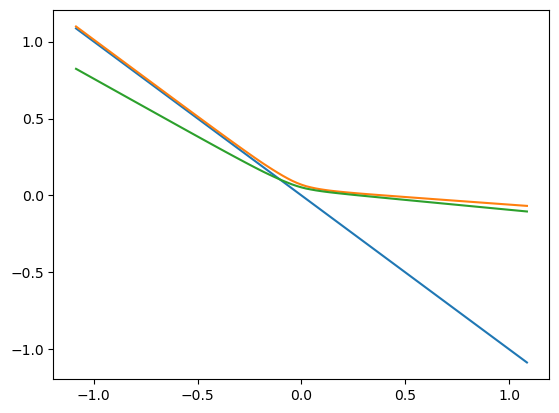

In [43]:


for t in fig2_cache['time_points']:
    y = fig2_eval_evoked['inoutmaps'][t,0,:] *this_input_scale
    x = these_probe_values * this_input_scale
    plt.plot(x, y-x)
    np.savetxt(os.path.join(savepath, f'ER_drift_{t}.txt'), np.stack((x, y-x)).T)
    np.savetxt(os.path.join(savepath, f'ER_inoutmap_{t}.txt'), np.stack((x, y)).T)

NameError: name 'evoked_a_exp' is not defined

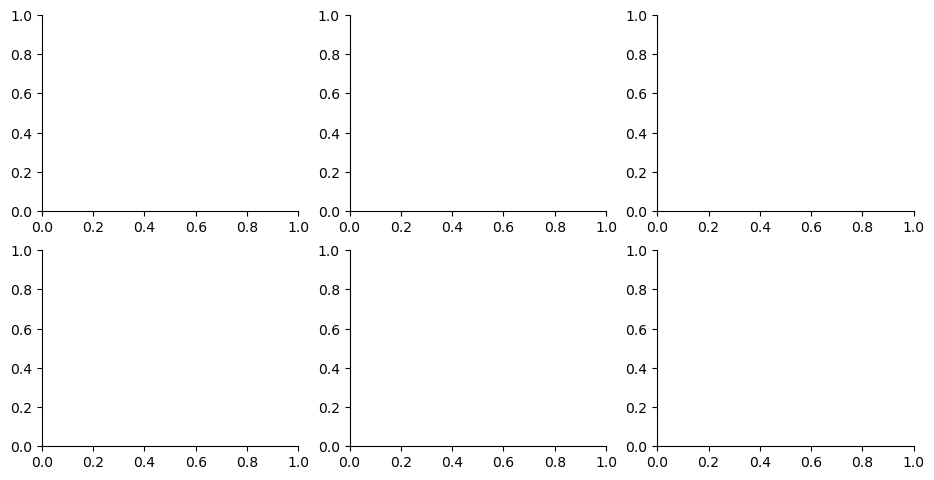

In [44]:

# FIG 2 draw:
# Safe to rerun and tweak without recomputing the paradigm simulations above.

if 'fig2_cache' not in globals():
    raise RuntimeError('Run the FIG 2 compute cell first to populate fig2_cache.')

plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
})

def phase_segments_from_paradigm(paradigm, zero_tol=1e-8):
    sign_code = np.zeros(len(paradigm), dtype=int)
    sign_code[np.asarray(paradigm) > zero_tol] = 1
    sign_code[np.asarray(paradigm) < -zero_tol] = -1

    segments = []
    start = 0
    current_sign = sign_code[0]
    for idx in range(1, len(sign_code) + 1):
        if idx == len(sign_code) or sign_code[idx] != current_sign:
            segments.append((start, idx - 1, current_sign))
            if idx < len(sign_code):
                start = idx
                current_sign = sign_code[idx]
    return segments

def add_phase_shading(ax, paradigm):
    for start, end, sign_code in phase_segments_from_paradigm(paradigm):
        left = start - 0.5
        right = end + 0.5
        if sign_code == 0:
            ax.axvspan(left, right, color='0.8', alpha=0.08, zorder=0)
        elif sign_code > 0:
            ax.axvspan(left, right, color='tab:green', alpha=0.08, zorder=0)
        else:
            ax.axvspan(left, right, color='tab:red', alpha=0.06, zorder=0)

def add_channel_markers(ax, paradigm, channel_offset=0.045):
    seen_nonzero = False
    for start, end, sign_code in phase_segments_from_paradigm(paradigm):
        if sign_code != 0:
            seen_nonzero = True
            continue
        if not seen_nonzero:
            continue
        ax.hlines(
            [channel_offset, -channel_offset],
            start - 0.5,
            end + 0.5,
            colors='k',
            linewidth=2.0,
            linestyles='--',
            alpha=0.6,
            zorder=2,
        )
        ax.hlines(
            [0],
            start - 0.5,
            end + 0.5,
            colors='tab:green',
            linewidth=2.0,
            linestyles='--',
            alpha=0.6,
            zorder=2,
        )

time_points = fig2_cache['time_points']
subj_idxs = fig2_cache['subj_idxs']
swapped_paradigms = fig2_cache['swapped_paradigms']
all_evals = fig2_cache['all_evals']

pnt_size = 50
map_lims = [-1.2, 1.2]
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(time_points)))

fig, axes = plt.subplots(2, 3, figsize=(ufigx*3,ufigy*2))

for row_idx, (name, eval_result) in enumerate(all_evals.items()):
    subj_idx = subj_idxs[name]
    trial_idx = np.asarray(eval_result['trial_idx'])
    outputs = eval_result['outputs'][:, subj_idx]
    flipper = np.sign(np.nanmean(outputs[:150]))
    fixed_points = eval_result['fixed_points'][:, subj_idx]
    paradigm = np.asarray(eval_result['paradigm'])
    experiment = np.asarray(evoked_a_exp[subj_idx]) if name.startswith('evoked') else np.asarray(spontaneous_a_exp[subj_idx-8])

    outputs = outputs * flipper  # ensure same sign convention as model
    experiment = experiment * flipper  # ensure same sign convention as model
    fixed_points = fixed_points * flipper  # ensure same sign convention as model
    these_probe_values = fig2_cache['probe_values'] * flipper  # ensure same sign convention as model
    paradigm = paradigm * flipper  # ensure same sign convention as model

    swapped_name = swapped_paradigms[name]
    swapped_eval = all_evals[swapped_name]
    swapped_outputs = swapped_eval['outputs'][:, subj_idx]
    swapped_flipper = np.sign(np.nanmean(swapped_outputs[:150]))
    swapped_outputs = swapped_outputs * swapped_flipper  # ensure same sign convention as model
    swapped_trial_idx = np.asarray(swapped_eval['trial_idx'])

    # 1) In-out map at required time points, with FIG 1 markers.
    ax_map = axes[row_idx, 1]
    for color, t in zip(colors, time_points):
        if not (0 <= t < eval_result['inoutmaps'].shape[0]):
            continue

        y_map = eval_result['inoutmaps'][t, subj_idx, :] * flipper  # ensure same sign convention as model
        ax_map.plot(
            these_probe_values,
            y_map,
            color=color,
            linewidth=2.0,
            alpha=0.95,
            label=f't={t}',
        )

        ax_map.scatter(
            fixed_points[t],
            fixed_points[t],
            s=pnt_size,
            color=color,
            edgecolor='white',
            linewidth=0.6,
            zorder=6,
        )

        if np.isfinite(paradigm[t]):
            idx_input = np.argmin(np.abs(these_probe_values - paradigm[t]))
            # ax_map.scatter(
            #     these_probe_values[idx_input],
            #     y_map[idx_input],
            #     s=pnt_size,
            #     color=color,
            #     marker='d',
            #     edgecolor='white',
            #     linewidth=0.6,
            #     zorder=6,
            # )

    ax_map.plot(these_probe_values, these_probe_values, 'k:', linewidth=1.2, alpha=0.6)
    ax_map.set_xlim(map_lims)
    ax_map.set_ylim(map_lims)
    ax_map.grid(alpha=0.2)
    # ax_map.set_title(f'{name}: in-out map')
    # ax_map.set_xlabel('input')
    # ax_map.set_ylabel('output')
    # ax_map.legend(frameon=False, loc='best')

    # 2) Adaptation plot (actual output, swapped output, and fixed point).
    ax_adapt = axes[row_idx, 2]
    add_phase_shading(ax_adapt, paradigm)
    ax_adapt.plot(
        trial_idx,
        outputs,
        color='tab:blue',
        linewidth=2.5,
        alpha=0.8,
        label='output',
    )
    # ax_adapt.plot(
    #     swapped_trial_idx,
    #     swapped_outputs,
    #     color='tab:blue',
    #     linewidth=1.5,
    #     alpha=0.65,
    #     linestyle='--',
    #     label=f'{swapped_name} output',
    # )
    ax_adapt.plot(
        trial_idx,
        fixed_points,
        color='tab:orange',
        linewidth=2.5,
        alpha=0.8,
        label='fixed point',
    )

    for color, t in zip(colors, time_points):
        if 0 <= t < len(trial_idx):
            # ax_adapt.scatter(
            #     trial_idx[t],
            #     outputs[t],
            #     s=pnt_size,
            #     color=color,
            #     marker='d',
            #     edgecolor='white',
            #     linewidth=0.6,
            #     zorder=6,
            # )
            ax_adapt.scatter(
                trial_idx[t],
                fixed_points[t],
                s=pnt_size,
                color=color,
                edgecolor='white',
                linewidth=0.6,
                zorder=6,
            )

    #plot experimental data with black dots
    # ax_adapt.plot(experiment,'.',  color='k', linewidth=1.0, alpha=0.3, label='experiment')

    ax_adapt.grid(alpha=0.2)
    # ax_adapt.set_title(f'{name}: adaptation')
    # ax_adapt.set_xlabel('trial')
    # ax_adapt.set_ylabel('adaptation')
    # ax_adapt.legend(frameon=False, loc='best')

    # 3) Paradigm plot
    ax_par = axes[row_idx, 0]
    add_phase_shading(ax_par, paradigm)
    ax_par.plot(trial_idx, paradigm, color='tab:green', linewidth=2.0, alpha=0.95)
    add_channel_markers(ax_par, paradigm)

    for color, t in zip(colors, time_points):
        if 0 <= t < len(trial_idx):
            # ax_par.scatter(
            #     trial_idx[t],
            #     paradigm[t],
            #     s=pnt_size * 0.8,
            #     color=color,
            #     marker='d',
            #     edgecolor='white',
            #     linewidth=0.6,
            #     zorder=6,
            # )
            pass

    ax_par.grid(alpha=0.2)
    # ax_par.set_title(f'{name}: paradigm')
    # ax_par.set_xlabel('trial')
    # ax_par.set_ylabel('perturbation')

for ax_row in axes:
    for ax in ax_row:
        ax.tick_params(axis='y', which='both', direction='in', right=False)
        ax.tick_params(axis='x', which='both', direction='in', top=False)

# fig.suptitle('FIG 2: evoked and spontaneous analyses at t = 174, 176, 190, 194', y=1.02)

# fig.savefig('fig2vJn3.svg', format='svg', bbox_inches='tight')
